# Gallstone Final Report
- **Group 18**
    - Timothy
    - Elmeri
    - Xudong Ma
    - Miguel
- **STAT 301**
- **Dec 6 2025**

## Introduction
#### Summary
- The dataset assigned to our group is about Gallstone Disease by Esen, Irfan, et al. It contains bioimpedance and laboratory data to develop machine learning models for predicting gallstone disease, which was served as an alternative diagnostic approach to traditional imaging techniques such as ultrasonography, CT, and MRI (Esen, Irfan, et al.). Specifically, the dataset contains 319 observations of which 161 are gallstone patients and 158 are healthy controls (Esen, Irfan, et al.). Furthermore, the dataset includes 38 variables with no missing values (Esen, Irfan, et al.), and their name, type, and description are given in the table below:

#### Research Focus
- The primary focus of our question will be inference. We want to understand and quantify the relationship between each predictor and the odds of having gallstones. Specifically, we aim to determine which predictors are statistically significantly associated with gallstone disease.

#### Research Question
- Which bioimpedance measurements and laboratory biomarkers are significantly associated with gallstone disease?

#### Source & Information
- This dataset originates from a prospective descriptive study conducted at the Internal Medicine Outpatient Clinic of Ankara VM Medical Park Hospital between June 2022 and June 2023 (Esen, Irfan, et al.) From an initial 454 participants, 134 individuals who had undergone gallbladder surgery were excluded, resulting in the final dataset of 319 observations of which 161 are gallstone patients and 158 are healthy controls (Esen, Irfan, et al.).
- **Citation**
    - Esen, Irfan, et al. "Gallstone." UCI Machine Learning Repository, 2024, https://doi.org/10.1097/md.0000000000037258.

## Methods and Results

### Data

In [1]:
# load required libraries
library(readxl)
library(car)
library(tidyverse)
library(ggplot2)
library(reshape2)
library(patchwork)
library(broom)


# set plot size
options(repr.plot.width = 15, repr.plot.height = 12)

Loading required package: carData

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::recode() masks car::recode()
✖ purrr::some()   masks car::some()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




In [2]:
# Download the zip file containing the dataset
outer_zip <- tempfile(fileext = ".zip")
download.file(
  "https://archive.ics.uci.edu/static/public/1150/gallstone-1.zip",
  outer_zip,
  mode = "wb"
)

# Unzip the outer zip into tempdir
tmp <- tempdir()
unzip(outer_zip, exdir = tmp)

# Locate the inner ZIP (dataset-uci.zip)
inner_zip <- list.files(
  tmp,
  pattern = "dataset-uci\\.zip$",
  full.names = TRUE,
  recursive = TRUE
)
inner_zip <- inner_zip[1]

# Unzip the inner zip file
unzip(inner_zip, exdir = tmp)

# Locate the xlsx data file
xlsx_path <- list.files(
  tmp,
  pattern = "dataset-uci\\.xlsx$",
  full.names = TRUE,
  recursive = TRUE
)

xlsx_path <- xlsx_path[1]

# Read the Excel file
gallstone_data <- read_xlsx(xlsx_path)

head(gallstone_data)

Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,⋯,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,50,0,0,0,0,0,0,185,92.8,⋯,40,134,20,22,87,0.82,112.47,0,16.0,33.0
0,47,0,1,0,0,0,0,176,94.5,⋯,43,103,14,13,46,0.87,107.10,0,14.4,25.0
0,61,0,0,0,0,0,0,171,91.1,⋯,43,69,18,14,66,1.25,65.51,0,16.2,30.2
0,41,0,0,0,0,0,0,168,67.7,⋯,59,53,20,12,34,1.02,94.10,0,15.4,35.4
0,42,0,0,0,0,0,0,178,89.6,⋯,30,326,27,54,71,0.82,112.47,0,16.8,40.6
0,96,0,0,0,0,0,0,155,49.0,⋯,30,65,13,13,60,1.46,43.74,0,11.0,45.8


<span style="background-color: #ffff99;">**Pre-selection of variables**</span>

In [3]:
# Check for correlation
corr_matrix_gallstone <- 
   gallstone_data %>%
   select(-`Gallstone Status`) %>% 
   cor() %>%
   as_tibble(rownames = 'var1') %>%
   pivot_longer(-var1, names_to = "var2", values_to = "corr")

head(corr_matrix_gallstone)
tail(corr_matrix_gallstone)

var1,var2,corr
<chr>,<chr>,<dbl>
Age,Age,1.000000000
Age,Gender,0.086144150
Age,Comorbidity,0.325446852
Age,Coronary Artery Disease (CAD),0.129635954
Age,Hypothyroidism,0.005289324
Age,Hyperlipidemia,0.015660354


var1,var2,corr
<chr>,<chr>,<dbl>
Vitamin D,Alkaline Phosphatase (ALP),-0.08185225
Vitamin D,Creatinine,0.09206745
Vitamin D,Glomerular Filtration Rate (GFR),-0.06663290
Vitamin D,C-Reactive Protein (CRP),-0.05123535
Vitamin D,Hemoglobin (HGB),0.03318717
Vitamin D,Vitamin D,1.00000000


In [4]:
# Find distinct variables with correlation > 0.65
# We will remove these variables from our model
cor_high_vars <- corr_matrix_gallstone %>%
    filter(abs(corr) > 0.65,
           var1 != var2) %>%
    pivot_longer(cols = c(var1, var2), values_to = "variable") %>%
    distinct(variable) %>%
    pull(variable)

cor_high_vars

[1] "Gender"                             "Height"                            
 [3] "Total Body Water (TBW)"             "Extracellular Water (ECW)"         
 [5] "Intracellular Water (ICW)"          "Bone Mass (BM)"                    
 [7] "Muscle Mass (MM)"                   "Hemoglobin (HGB)"                  
 [9] "Visceral Muscle Area (VMA) (Kg)"    "Weight"                            
[11] "Body Mass Index (BMI)"              "Visceral Fat Rating (VFR)"         
[13] "Total Fat Content (TFC)"            "Visceral Fat Area (VFA)"           
[15] "Total Body Fat Ratio (TBFR) (%)"    "Lean Mass (LM) (%)"                
[17] "Body Protein Content (Protein) (%)" "Total Cholesterol (TC)"            
[19] "Low Density Lipoprotein (LDL)"      "Aspartat Aminotransferaz (AST)"    
[21] "Alanin Aminotransferaz (ALT)"

In [5]:
# Remove variables with high correlation from gallstone dataframe
gallstone_pre_selection <- gallstone_data %>%
    select(-all_of(cor_high_vars))

head(gallstone_pre_selection)

Gallstone Status,Age,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Extracellular Fluid/Total Body Water (ECF/TBW),Obesity (%),Hepatic Fat Accumulation (HFA),Glucose,High Density Lipoprotein (HDL),Triglyceride,Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Vitamin D
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,50,0,0,0,0,0,40,23.4,0,102,40,134,87,0.82,112.47,0,33.0
0,47,1,0,0,0,0,45,38.8,0,94,43,103,46,0.87,107.10,0,25.0
0,61,0,0,0,0,0,43,41.7,0,103,43,69,66,1.25,65.51,0,30.2
0,41,0,0,0,0,0,41,9.0,1,69,59,53,34,1.02,94.10,0,35.4
0,42,0,0,0,0,0,39,28.6,2,109,30,326,71,0.82,112.47,0,40.6
0,96,0,0,0,0,0,46,7.4,0,74,30,65,60,1.46,43.74,0,45.8


In [6]:
# Check for variable with generalized VIF higher than sqrt(5)
# We will exclude these variales from our model
vif_values <- glm(formula = `Gallstone Status` ~ ., data = gallstone_pre_selection, family = binomial) %>%
    vif()

vif_high <- vif_values[vif_values > sqrt(5)]

vif_high

Comorbidity `Diabetes Mellitus (DM)` 
                2.282136                 2.553878

In [7]:
# Remove variable with high generalized VIF
gallstone_pre_selection <- gallstone_pre_selection %>%
    select(-Comorbidity, -`Diabetes Mellitus (DM)`)

# These are the variables we'll be working with in our model
colnames(gallstone_pre_selection)

[1] "Gallstone Status"                              
 [2] "Age"                                           
 [3] "Coronary Artery Disease (CAD)"                 
 [4] "Hypothyroidism"                                
 [5] "Hyperlipidemia"                                
 [6] "Extracellular Fluid/Total Body Water (ECF/TBW)"
 [7] "Obesity (%)"                                   
 [8] "Hepatic Fat Accumulation (HFA)"                
 [9] "Glucose"                                       
[10] "High Density Lipoprotein (HDL)"                
[11] "Triglyceride"                                  
[12] "Alkaline Phosphatase (ALP)"                    
[13] "Creatinine"                                    
[14] "Glomerular Filtration Rate (GFR)"              
[15] "C-Reactive Protein (CRP)"                      
[16] "Vitamin D"

<span style="background-color: #ffff99;">**End of Pre-selection of variables**</span>

#### About the data

The dataset contains clinical data collected from the Internal Medicine Outpatient Clinic of Ankara VM Medical Park Hospital. The data represent 319 individuals with 116 individuals diagnosed with gallstone disease. There are 38 features representing demographic, biological, and laboratory data.

Citation:

Esen, I., Arslan, H., Aktürk, S., Gülşen, M., Kültekin, N., & Özdemir, O. (2024). Gallstone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.1097/md.0000000000037258.

| Variable Name | Type | Description | Number of Observations |
|---------------|------|-------------|------------------------|
| Gallstone Status | Binary | Gallstones present (0) or absent (1) | 319 |
| Age | Integer | Age of the person | 319 |
| Gender | Categorical | Gender of the person | 319 |
| Comorbidity | Categorical | Other diseases that the person has: 0 (No comorbidities present), 1 (One comorbid condition), 2 (Two comorbid conditions), 3 (Three or more comorbid conditions)| 319 |
| Coronary Artery Disease (CAD) | Binary | Cardiovascular disease: 0 (No), 1 (Yes)| 319 |
| Hypothyroidism | Binary | Underactive thyroid gland: 0 (No), 1 (Yes) | 319 |
| Hyperlipidemia | Binary | High levels of fat in the blood: 0 (No), 1 (Yes) | 319 |
| Diabetes Mellitus (DM) | Binary | High blood sugar: 0 (No), 1 (Yes) | 319 |
| Height | Integer | Height in cm | 319|
| Weight | Numeric | Weight in kg | 319|
| Body Mass Index (BMI) | Numeric | Weight to height ratio | 319 |
| Total Body Water (TBW) | Numeric | Total water in the body | 319 |
| Extracellular Water (ECW) | Numeric | Extracellular water | 319 |
| Intracellular Water (ICW) | Numeric | Intracellular water | 319 |
| Extracellular Fluid/Total Body Water (ECF/TBW) | Numeric | Extracellular water content | 319 |
| Total Body Fat Ratio (TBFR) (%) | Numeric | Total fat content (%) | 319 |
| Lean Mass (LM) (%) | Numeric | Lean body mass (%) | 319 |
| Body Protein Content (Protein) (%) | Numeric | Body protein content (%) | 319 |
| Visceral Fat Rating (VFR) | Integer | Visceral organ fat level | 319 |
| Bone Mass (BM) | Numeric | Mass of bones | 319 |
| Muscle Mass (MM) | Numeric | Muscle mass | 319 |
| Obesity (%) | Numeric | Excess fat (%) | 319 |
| Total Fat Content (TFC) | Numeric | Total fat amount | 319 |
| Visceral Fat Area (VFA) | Numeric | Inner adipose tissue area | 319 |
| Visceral Muscle Area (VMA) (Kg) | Numeric | Inner muscle area (kg) | 319 |
| Hepatic Fat Accumulation (HFA) | Categorical | Accumulation of fat in the liver: 0 (No fat accumulation),1 (Grade 1 (mild)), 2 (Grade 2 (moderate)), 3 (Grade 3 (severe)), 4 (Grade 4 (very severe)) | 319 |
| Glucose | Numeric | Blood sugar | 319 |
| Total Cholesterol (TC) | Numeric | Total cholesterol amount | 319 |
| Low Density Lipoprotein (LDL) | Numeric | Amount of "bad" cholesterol | 319 |
| High Density Lipoprotein (HDL) | Numeric | Amount of "good" cholesterol | 319 |
| Triglyceride | Numeric | Amount of trigliceride fats found in blood | 319 |
| Aspartate Aminotransferase (AST) | Numeric | Amount of liver enzyme | 319 |
| Alanine Aminotransferase (ALT) | Numeric | Amount of liver enzyme | 319 |
| Alkaline Phosphatase (ALP) | Numeric | Amount of liver and bone enzyme | 319 |
| Creatinine | Numeric | Kidney function indicator | 319 |
| Glomerular Filtration Rate (GFR) | Numeric | Kidney filtration rate | 319 |
| C-Reactive Protein (CRP) | Numeric | Inflammation indicator | 319 |
| Hemoglobin (HGB) | Numeric | Protein that carries oxygen in the blood | 319 |
| Vitamin D | Numeric | Essential vitamin for bone health | 319 |

#### Variable Selection
- Response
  - Gallstone status

- Predictors of interest
  - Lipid panel: TC, LDL, HDL, Triglyceride
  - Liver enzymes: AST, ALT, ALP
  - Blood lab: CRP, Creatinine or GFR, HGB, Vitamin D
  - Age, Sex

- Exclusions
  - Other body-composition/comorbidity variables to keep the analysis focused

### Exploratory Data Analysis(EDA)

In [10]:
exploratory_data <- gallstone_pre_selection

# rename columns for easier reference
colnames(exploratory_data) <- c("gallstone_status",  # Gallstone Status
                                "age",               # Age
                                "cad",               # Coronary Artery Disease
                                "hypothyroidism",    # Hypothyroidism
                                "hyperlipidemia",    # Hyperlipidemia
                                "ecf_tbw",           # Extracellular Fluid/Total Body Water
                                "obesity_pct",       # Obesity (%)
                                "hfa",               # Hepatic Fat Accumulation
                                "glucose",           # Glucose
                                "hdl",               # High Density Lipoprotein
                                "triglyceride",      # Triglyceride
                                "alp",               # Alkaline Phosphatase
                                "creatinine",        # Creatinine
                                "gfr",               # Glomerular Filtration Rate
                                "crp",               # C-Reactive Protein
                                "vit_d")             # Vitamin D

# recode binary variables as factors
exploratory_data$gallstone_status <- factor(exploratory_data$gallstone_status,
                                    levels = 0:1,
                                    labels = c("Yes", "No"))

head(exploratory_data)

gallstone_status,age,cad,hypothyroidism,hyperlipidemia,ecf_tbw,obesity_pct,hfa,glucose,hdl,triglyceride,alp,creatinine,gfr,crp,vit_d
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Yes,50,0,0,0,40,23.4,0,102,40,134,87,0.82,112.47,0,33.0
Yes,47,0,0,0,45,38.8,0,94,43,103,46,0.87,107.10,0,25.0
Yes,61,0,0,0,43,41.7,0,103,43,69,66,1.25,65.51,0,30.2
Yes,41,0,0,0,41,9.0,1,69,59,53,34,1.02,94.10,0,35.4
Yes,42,0,0,0,39,28.6,2,109,30,326,71,0.82,112.47,0,40.6
Yes,96,0,0,0,46,7.4,0,74,30,65,60,1.46,43.74,0,45.8


In [11]:
# show summary of the data
summary(exploratory_data)

 gallstone_status      age             cad          hypothyroidism   
 Yes:161          Min.   :20.00   Min.   :0.00000   Min.   :0.00000  
 No :158          1st Qu.:38.50   1st Qu.:0.00000   1st Qu.:0.00000  
                  Median :49.00   Median :0.00000   Median :0.00000  
                  Mean   :48.07   Mean   :0.03762   Mean   :0.02821  
                  3rd Qu.:56.00   3rd Qu.:0.00000   3rd Qu.:0.00000  
                  Max.   :96.00   Max.   :1.00000   Max.   :1.00000  
 hyperlipidemia       ecf_tbw       obesity_pct           hfa      
 Min.   :0.00000   Min.   :29.23   Min.   :   0.40   Min.   :0.00  
 1st Qu.:0.00000   1st Qu.:40.08   1st Qu.:  13.90   1st Qu.:0.00  
 Median :0.00000   Median :42.00   Median :  25.60   Median :1.00  
 Mean   :0.02508   Mean   :42.21   Mean   :  35.85   Mean   :1.15  
 3rd Qu.:0.00000   3rd Qu.:44.00   3rd Qu.:  41.75   3rd Qu.:2.00  
 Max.   :1.00000   Max.   :52.00   Max.   :1954.00   Max.   :4.00  
    glucose           hdl         

In [12]:
# create boxplots for each predictor by gallstone status
boxplots <- exploratory_data %>%
  pivot_longer(cols = -c(gallstone_status, age), names_to = "predictor", values_to = "value") %>%
  ggplot(aes(x = gallstone_status, y = value, fill = gallstone_status)) +
  geom_boxplot() +
  facet_wrap(~ predictor, scales = "free") +
  labs(x = NULL, y = "Value", fill = "Gallstone Status") +
  ggtitle("Boxplots of Predictors by Gallstone Status")

In [13]:
# create a plot of age distribution by sex and gallstone status
age_sex_plot <- exploratory_data %>%
  ggplot(aes(x = age, fill = gallstone_status)) +
  geom_density(alpha=0.5) +
  labs(x = "Age", y = "Count", fill = "Gallstone Status") +
  ggtitle("Age Distribution by gallstone status")

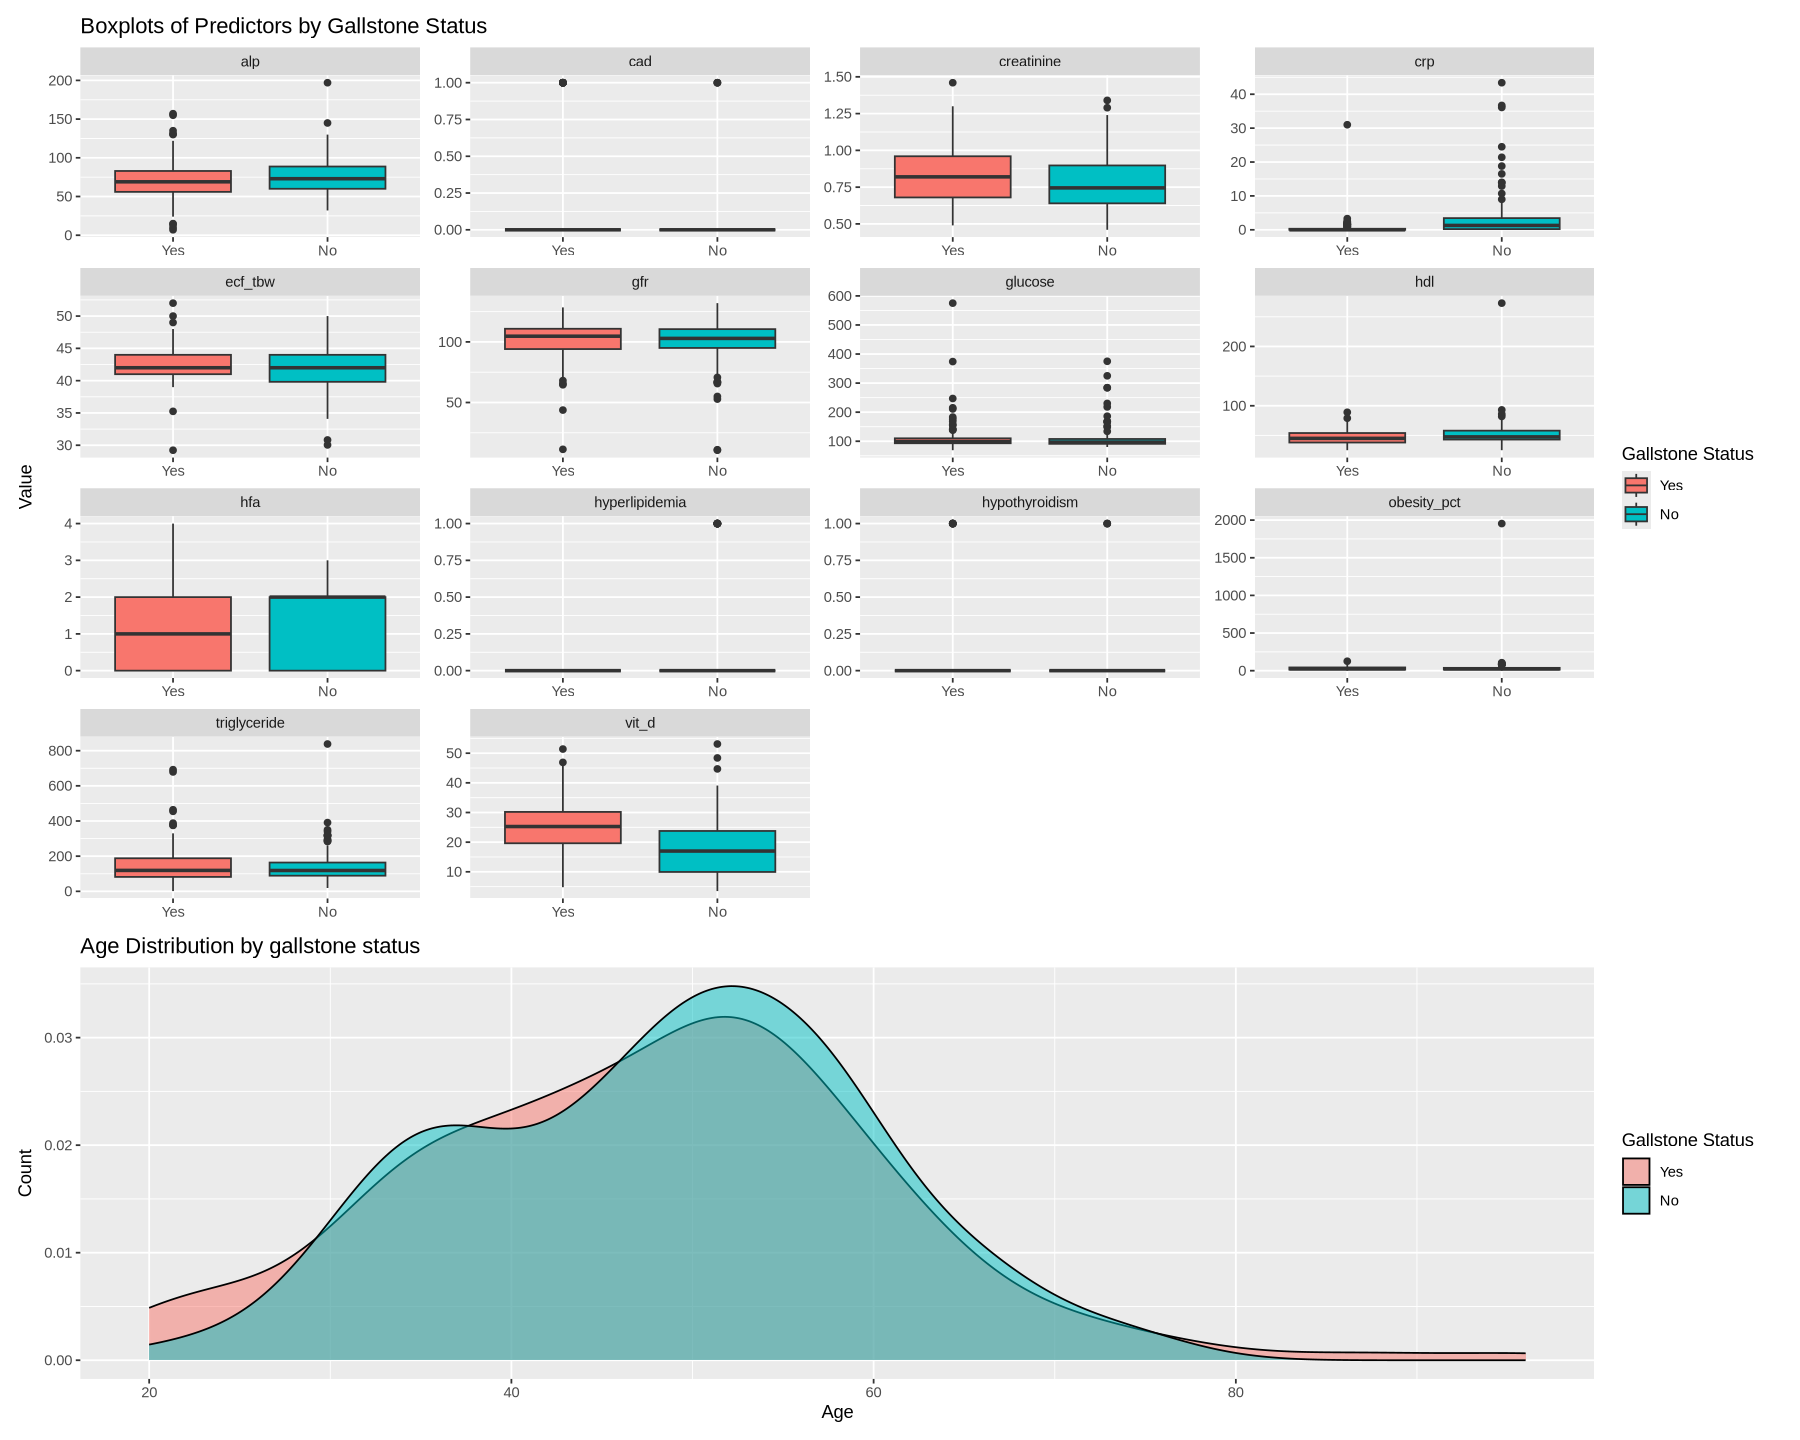

In [14]:
# generate a composite figure using the two previous plots
fig <- wrap_plots(boxplots, age_sex_plot, 
           ncol = 1, nrow = 2,
           widths = c(1, 1), heights = c(1, 0.5))

fig

The boxplots above show the distribution and spread of each continuous predictor by gallstone status. Boxplots are useful for comparing distributions between groups because they clearly display medians, quartiles, and outliers, making it easy to identify potential associations and detect skewness that might require transformation.

The density plots for age show smooth, overlapping distributions by gallstone status within each sex group. These plots can be used to compare distribution shapes and peaks between overlapping groups to assess whether age distributions differ by gallstone status and sex.

The boxplots above illustrate the distribution of different numeric variables by gallstone status. From the boxplots we can see that most of the selected variables have similar distributions between the two gallstone groups, suggesting that there may be colinearity between the variables. A few exceptions are the liver enzymes AST/ALT/ALP, creatinine, C-reactive protein (CRP), Hemoglobin (HGB), and vitamin-D, so these may be associated with gallstone status. Several variables (liver enzymes, CRP, HDL, and triglycerides) are skewed and contain outliers, so a log transform may be needed to interpret these better. 

The histograms show the distribution of age by gallstone status and sex. The age distributions are very similar between the 2 gallstone status groups for both males and females, suggesting that age may not be a factor in gallstone status on its own. The most common age for patients in the dataset is between 50-60 years old. There seem to be two different peaks within the age distributions, so it may be worthwhile to group the ages (e.g. <=50 and >50).

## Methods: Plan


### Method Overview
**Model Choice (Logistic Regression)**  
   Because the response (Gallstone Status) is binary, we use a logistic regression model within the GLM framework.

2. **Model Construction (Four Candidate Models)**  
   We fit four models:  
   - Full model  
   - Reduced model 1  
   - Reduced model 2  
   - Interaction model (e.g., Age × Sex)

3. **Model Comparison (Deviance Test / ANOVA)**  
   We compare the full and reduced models using the Likelihood Ratio Test based on deviance to identify which model provides the best balance of fit and parsimony.

4. **Model Diagnostics (Before Finalizing Model)**  
   For the best-performing model(s), we conduct diagnostic checks:  
   - Multicollinearity (VIF / GVIF)  
   - Linearity in the logit for continuous predictors  
   - Deviance residual patterns to check for misspecification  
   - Influence measures (Cook’s distance) to detect influential observations  
   Only models that pass diagnostic checks can be considered as final candidates.

5. **Coefficient Interpretation (Final Model Only)**  
   After diagnostics confirm model validity, we interpret effect estimates (coefficients, odds ratios, p-values, confidence intervals) to determine the direction and magnitude of associations between covariates and gallstone risk.





### Model and Covariates

Given that the response variable *Gallstone Status* is binary (0 = no gallstones, 1 = gallstones), we will use a **Generalized Linear Model (GLM)** with a **binomial family** and **logit**. This model is appropriate for estimating the association between multiple predictors and the log-odds of gallstone presence.

We will include covariates that are biologically plausible contributors to gallstone risk. These include(full model):

- **Demographics:** Age, Sex  
  - **Age:** Older age is associated with a higher risk of gallstones, partly due to decreased gallbladder motility and increased bile concentration with aging.  
  - **Sex:** Females have a higher prevalence of gallstones, largely influenced by estrogen, which alters bile composition and promotes cholesterol supersaturation.

- **Lipid panel:** Total Cholesterol (TC), LDL, HDL, Triglycerides  
  - Gallstones, particularly cholesterol stones, are strongly linked to abnormalities in lipid metabolism.  
  - Excess cholesterol in bile increases the likelihood of cholesterol crystallization and stone formation.

- **Liver enzymes:** AST, ALT, ALP  
  - The liver produces and secretes bile; therefore, liver dysfunction can alter bile composition.  
  - Elevated ALP may indicate biliary obstruction or cholestasis, conditions commonly associated with gallstone disease.

- **Inflammatory and metabolic markers:** CRP, Creatinine (or GFR), Hemoglobin (HGB), Vitamin D  
  - **CRP:** A marker of systemic inflammation; chronic inflammation may influence bile metabolism and gallstone risk.  
  - **Creatinine / GFR:** Although not direct hepatobiliary markers, kidney function reflects overall metabolic health, which can modulate gallstone risk.  
  - **Hemoglobin (HGB):** Abnormal hemoglobin levels, especially in hemolytic conditions, can alter bilirubin metabolism and contribute to pigment stone formation.  
  - **Vitamin D:** Emerging evidence links Vitamin D to lipid metabolism and inflammatory pathways, both of which may influence gallstone development.
Model Specification & Selection Plan
We will  compare several possible models. Specifically, we will consider:

1. **Full model** – including all covariates listed above.  
2. **Reduced model(s)** – excluding covariates with weaker theoretical or biological justification, to assess model stability.  
3. **interaction model** – evaluating the *Age × Sex* interaction if supported by literature or biological reasoning.

These models will allow us to examine how the estimated associations change under different but theory-motivated model specifications.



### Rationale for Removing Creatinine/GFR and Hemoglobin in the Reduced Model1

In the reduced model, we excluded **Creatinine/GFR** and **Hemoglobin (HGB)** based on biological
plausibility rather than statistical significance. These variables are not central to the established
mechanisms of cholesterol gallstone formation.

- **Creatinine / GFR:** Indicators of kidney function that do not directly influence bile production,
bile flow, or cholesterol supersaturation—the primary pathways leading to gallstones.

- **Hemoglobin (HGB):** Primarily relevant for pigment stones via hemolysis and bilirubin metabolism.
This mechanism is less applicable to typical cholesterol gallstones in our dataset.

Removing these weaker, less directly related predictors results in a more parsimonious and clinically
coherent model. The suitability of this reduced model will be evaluated using a Likelihood Ratio Test
against the full model.


### Rationale for Removing Age/Sex  in the Reduced Model2
In Reduced Model 2, we remove **Age** and **Sex** to isolate the contribution of clinical biomarkers.
Although both variables are known population-level risk factors for gallstones, their role in our model
may be limited for the following reasons:

- **Redundancy:** Age is closely related to several metabolic markers (e.g., lipid levels, liver
enzymes), so its explanatory information may already be captured by these covariates.

- **Weaker within-sample variation:** In a relatively homogeneous clinical population, Sex differences
may contribute less to variation in gallstone status compared with physiological measurements.

- **Focus on biochemical predictors:** Excluding demographic variables allows us to evaluate whether
biomarkers alone can adequately explain gallstone risk.

This model provides an alternative specification to compare against the full model using the Likelihood
Ratio Test.

### Rationale for Including the Age × Sex Interaction model

In the interaction model, we include an **Age × Sex** term to allow the effect of age on gallstone risk to
vary between males and females. This interaction is biologically plausible because:

- **Hormonal differences** between sexes may influence how aging affects bile composition and
cholesterol metabolism.  
- **Gallstone prevalence increases with age**, but the rate of increase may differ between men and
women due to estrogen-related effects.
- Including the interaction allows the model to capture potential **non-parallel age trends** across sexes
that a main-effects-only model would miss.

The interaction term is therefore tested to determine whether demographic factors jointly modify the
relationship between age and gallstone status.

We compare models using the Deviance Test (Likelihood Ratio Test). The interpretation is as follows:

- **If the p-value is small**, this indicates that the reduced model loses important explanatory 
  information, and therefore the **full model** provides a better overall fit.

- **If the p-value is large (not significant)**, the reduced model performs similarly to the full model 
  and may be preferred because it is **more parsimonious and easier to interpret**.

- It is important to note that **model selection via ANOVA only determines which covariates should be 
  included in the final model**. It does *not* reveal the direction (positive or negative) or the 
  magnitude of individual covariate effects.

Since we fitted four models (Full Model, Reduced Model 1, Reduced Model 2, and the Interaction Model),
we perform all possible pairwise comparisons to assess relative model fit. With four models, there are: 6 total pairwise comparisons:

1. Full Model vs Reduced Model 1  
2. Full Model vs Reduced Model 2  
3. Full Model vs Interaction Model  
4. Reduced Model 1 vs Reduced Model 2  
5. Reduced Model 1 vs Interaction Model  
6. Reduced Model 2 vs Interaction Model  

Each comparison evaluates whether one model provides a significantly better fit than the other based on 
the change in deviance.

Model Diagnostics (Before Finalizing the Model)

For the best-performing models, we conduct diagnostic checks:

- **Multicollinearity:** using VIF/GVIF  
- **Linearity in the logit:** using smoothed residual-vs-predictor plots  
- **Residual patterns:** checking for model misspecification  
- **Influential observations:** using Cook’s distance  

Only models that pass diagnostic checks are considered valid final candidates.

---

 Final Model Selection Criteria

The final model must satisfy:

- Strong theoretical/biological justification  
- Acceptable multicollinearity (VIF/GVIF)  
- Reasonable model fit (residual vs null deviance, pseudo R²)  
- No major diagnostic violations  
- Stable coefficients across competing models (full vs reduced)  
- Not rejected in the relevant deviance tests  

---

 Coefficient Interpretation (Final Model Only)

Once the final model is selected, we interpret:

- Estimated coefficients (log-odds)  
- Odds ratios  
- Confidence intervals  
- Statistical significance  

These quantities determine the direction and magnitude of associations between covariates and
gallstone risk.
